# Гибридная каскадная архитектура с CLIP zero-shot скорингом и conformal prediction

В данном ноуте реализуется и эмпирически проверяется **оригинальная двухстадийная каскадная архитектура** детекции контрафакта, состоящая из:

1. **Stage 1 — быстрый табличный скрининг** на CatBoost со структурными признаками от K-means (адаптация Mohd Amin et al. 2024 [1]).
2. **Stage 2 — zero-shot мультимодальный скоринг** через CLIP с ансамблем структурированных промптов для borderline-объектов из Stage 1.
3. **Conformal prediction calibration** на val для формальной гарантии FPR ≤ ε при заданном уровне уверенности.

## Что проверяется

- Можно ли использовать визуальную foundation-модель CLIP (Radford et al., 2021) в zero-shot режиме на маркетплейс-данных без какой-либо доменной адаптации.
- Сохраняет ли каскадная процедура «быстрый screening → дорогой стадий только для borderline-объектов» приемлемую production-латентность.
- Возможно ли через split conformal predictor зафиксировать формальные FPR-гарантии, регуляторно требуемые при автоматических действиях блокировки.

## Связь с темой ВКР

Тема диплома — «...с использованием больших мультимодальных моделей». CLIP представляет собой мультимодальную foundation model, обученную на 400 млн пар «изображение–текст», и её применимость к маркетплейс-задаче в zero-shot режиме непосредственно проверяется в данном ноуте. **Полученный отрицательный результат (см. § 14)** становится одним из двух центральных научных негативных результатов работы и эмпирически опровергает наивную гипотезу о механическом переносе foundation-модели в маркетплейс-домен без адаптации.

## 1. Setup

In [1]:
from pathlib import Path
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix
)
from sklearn.isotonic import IsotonicRegression
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
np.random.seed(SEED)

ROOT = Path('.')
DATA_PATH = ROOT / "data" / 'ml_ozon_ounterfeit_train.csv'
CLIP_PATH = ROOT / 'counterfeit_service' / 'clip_embeddings.parquet'
OUT_DIR = ROOT / 'new_diploma' / 'real_estate_approaches' / 'artifacts_original'
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'resolution'
CATEGORY_COL = 'CommercialTypeName4'

print('Data:', DATA_PATH.exists(), '| CLIP:', CLIP_PATH.exists())

Data: True | CLIP: True


## 2. Загрузка данных + seller-based split

Используем тот же сплит, что и в ноуте 02 для прямой сопоставимости.

In [2]:
df = pd.read_csv(DATA_PATH, encoding='utf-8')
df['text'] = (
    df['name_rus'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['brand_name'].fillna('')
)

# Seller-based split
seller_targets = df.groupby('SellerID')[TARGET].max().reset_index()
train_sellers, temp_sellers = train_test_split(
    seller_targets['SellerID'], test_size=0.30,
    random_state=SEED, stratify=seller_targets[TARGET]
)
temp_targets = seller_targets[seller_targets['SellerID'].isin(temp_sellers)]
val_sellers, test_sellers = train_test_split(
    temp_targets['SellerID'], test_size=0.50,
    random_state=SEED, stratify=temp_targets[TARGET]
)

train_df = df[df['SellerID'].isin(train_sellers)].copy().reset_index(drop=True)
val_df = df[df['SellerID'].isin(val_sellers)].copy().reset_index(drop=True)
test_df = df[df['SellerID'].isin(test_sellers)].copy().reset_index(drop=True)

y_train = train_df[TARGET].to_numpy()
y_val = val_df[TARGET].to_numpy()
y_test = test_df[TARGET].to_numpy()

for name, part, y in [('Train', train_df, y_train), ('Val', val_df, y_val), ('Test', test_df, y_test)]:
    print(f'{name:<6} n={len(part):>6}  positive_rate={y.mean():.4f}')

Train  n=144967  positive_rate=0.0665
Val    n= 25904  positive_rate=0.0687
Test   n= 26327  positive_rate=0.0620


## 3. Stage 1: Признаковая инженерия + K-means структурные признаки

**Адаптация [1] Mohd Amin et al. 2024:** K-means как препроцессинг → cluster_id и distance to centroid как дополнительные признаки в табличной модели.

In [3]:
def engineer_basic(frame, refs):
    out = frame.copy()
    # FADAML ценовые
    cat_median = out[CATEGORY_COL].map(refs['cat_med']).fillna(refs['global_med'])
    out['category_median_price'] = cat_median
    out['price_ratio'] = out['PriceDiscounted'].fillna(0) / cat_median.replace(0, np.nan).fillna(1)
    out['log_price_ratio'] = np.log1p(out['price_ratio'].clip(lower=0))
    out['price_too_low'] = (out['price_ratio'] < 0.5).astype(int)
    out['price_too_high'] = (out['price_ratio'] > 2.0).astype(int)
    # LOO
    out['category_target_mean'] = out[CATEGORY_COL].map(refs['cat_tgt']).fillna(refs['global_tgt'])
    out['brand_target_mean'] = out['brand_name'].map(refs['brand_tgt']).fillna(refs['global_tgt'])
    # Стилевые
    name = out['name_rus'].fillna('').str.lower()
    out['name_caps_ratio'] = out['name_rus'].fillna('').apply(lambda s: sum(c.isupper() for c in s) / max(len(s), 1))
    out['susp_kw'] = name.str.contains('оригинал|original|100%|гарантия', regex=True, na=False).astype(int)
    out['excl_count'] = out['description'].fillna('').str.count('!')
    # Длины
    for col in ['name_rus', 'description', 'brand_name']:
        out[f'{col}_len'] = out[col].fillna('').str.len()
        out[f'{col}_is_null'] = out[col].isna().astype(int)
    # Возвратные
    out['return_rate_30'] = out['item_count_returns30'].fillna(0) / (out['item_count_sales30'].fillna(0) + 1)
    out['return_rate_90'] = out['item_count_returns90'].fillna(0) / (out['item_count_sales90'].fillna(0) + 1)
    out['sales_velocity_30'] = out['item_count_sales30'].fillna(0) / (out['item_time_alive'].fillna(0) + 1)
    out['is_new_item'] = (out['item_time_alive'].fillna(0) <= 30).astype(int)
    out['is_new_seller'] = (out['seller_time_alive'].fillna(0) <= 180).astype(int)
    return out

refs = {
    'cat_med': train_df.groupby(CATEGORY_COL)['PriceDiscounted'].median(),
    'cat_tgt': train_df.groupby(CATEGORY_COL)[TARGET].mean(),
    'brand_tgt': train_df.groupby('brand_name')[TARGET].mean(),
    'global_med': train_df['PriceDiscounted'].median(),
    'global_tgt': train_df[TARGET].mean(),
}
train_df = engineer_basic(train_df, refs)
val_df = engineer_basic(val_df, refs)
test_df = engineer_basic(test_df, refs)

tab_feats = [
    'PriceDiscounted', 'item_time_alive', 'seller_time_alive',
    'item_count_sales30', 'item_count_sales90',
    'item_count_returns30', 'item_count_returns90',
    'GmvTotal30', 'GmvTotal90',
    'category_median_price', 'price_ratio', 'log_price_ratio', 'price_too_low', 'price_too_high',
    'category_target_mean', 'brand_target_mean',
    'name_caps_ratio', 'susp_kw', 'excl_count',
    'name_rus_len', 'description_len', 'brand_name_len',
    'name_rus_is_null', 'description_is_null', 'brand_name_is_null',
    'return_rate_30', 'return_rate_90', 'sales_velocity_30',
    'is_new_item', 'is_new_seller',
]

# Стандартизация
scaler = StandardScaler()
Xtr_tab = scaler.fit_transform(train_df[tab_feats].fillna(0))
Xv_tab = scaler.transform(val_df[tab_feats].fillna(0))
Xte_tab = scaler.transform(test_df[tab_feats].fillna(0))

# K-means structural features (адаптация Mohd Amin et al. 2024 [1])
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
ctr = kmeans.fit_predict(Xtr_tab)
cv = kmeans.predict(Xv_tab)
cte = kmeans.predict(Xte_tab)

fraud_cluster = int(pd.Series(y_train).groupby(ctr).mean().idxmax())
fraud_centroid = kmeans.cluster_centers_[fraud_cluster]

train_df['cluster_id'] = (ctr == fraud_cluster).astype(int)
val_df['cluster_id'] = (cv == fraud_cluster).astype(int)
test_df['cluster_id'] = (cte == fraud_cluster).astype(int)
train_df['dist_centroid'] = np.linalg.norm(Xtr_tab - fraud_centroid, axis=1)
val_df['dist_centroid'] = np.linalg.norm(Xv_tab - fraud_centroid, axis=1)
test_df['dist_centroid'] = np.linalg.norm(Xte_tab - fraud_centroid, axis=1)

tab_feats += ['cluster_id', 'dist_centroid']

print(f'K-means: fraud_cluster={fraud_cluster}, count in train={ctr.tolist().count(fraud_cluster)}, count in test={cte.tolist().count(fraud_cluster)}')
print(f'Total tabular features: {len(tab_feats)}')

K-means: fraud_cluster=0, count in train=33931, count in test=5107
Total tabular features: 32


## 4. Stage 1: Обучение быстрого CatBoost (screening classifier)

In [4]:
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

X_train_s1 = scaler.fit_transform(train_df[tab_feats].fillna(0))
X_val_s1 = scaler.transform(val_df[tab_feats].fillna(0))
X_test_s1 = scaler.transform(test_df[tab_feats].fillna(0))

t0 = time.time()
stage1 = CatBoostClassifier(
    iterations=1000, depth=6, learning_rate=0.05,
    eval_metric='AUC', scale_pos_weight=scale_pos, random_seed=SEED,
    early_stopping_rounds=80, verbose=False,
)
stage1.fit(X_train_s1, y_train, eval_set=(X_val_s1, y_val), use_best_model=True)
t_train_s1 = time.time() - t0

p_s1_val = stage1.predict_proba(X_val_s1)[:, 1]
p_s1_test = stage1.predict_proba(X_test_s1)[:, 1]

# Калибровка
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(p_s1_val, y_val)
p_s1_val_c = iso.transform(p_s1_val)
p_s1_test_c = iso.transform(p_s1_test)

roc_s1 = roc_auc_score(y_test, p_s1_test_c)
pr_s1 = average_precision_score(y_test, p_s1_test_c)
print(f'Stage 1 — CatBoost screening (только табличные + K-means structural)')
print(f'  Train time: {t_train_s1:.1f}s')
print(f'  Test: ROC-AUC={roc_s1:.4f}  PR-AUC={pr_s1:.4f}')

Stage 1 — CatBoost screening (только табличные + K-means structural)
  Train time: 1.9s
  Test: ROC-AUC=0.9407  PR-AUC=0.6312


## 5. Stage 2: CLIP zero-shot scoring

**Идея:** для каждого товара вычисляем zero-shot вероятность контрафакта через CLIP text-image similarity.

Два промпта (English, поскольку CLIP обучен на английском):
- `"authentic original branded product photograph"`
- `"counterfeit knockoff suspicious product photograph"`

Cosine similarity между image embedding и каждым text embedding → softmax → P(counterfeit | image).

**Подход без новой инференции:** изображения уже закодированы в `clip_embeddings.parquet`, нам нужны только text-эмбеддинги CLIP. Загружаем CLIP text encoder, кодируем два промпта (~1 секунда), считаем similarity матрично.

In [5]:
# CLIP image embeddings (предвычисленные)
clip_df = pd.read_parquet(CLIP_PATH)

def build_clip_matrix(frame, lookup, dim=512):
    merged = frame[['ItemID']].merge(lookup, on='ItemID', how='left')
    emb = merged['embedding'].apply(
        lambda x: x if isinstance(x, np.ndarray) else np.zeros(dim, dtype=np.float32)
    )
    return np.vstack(emb.values).astype(np.float32)

X_clip_train = build_clip_matrix(train_df, clip_df)
X_clip_val = build_clip_matrix(val_df, clip_df)
X_clip_test = build_clip_matrix(test_df, clip_df)

# L2-нормализация (для cosine similarity)
def normalize(x):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(n, 1e-8)

X_clip_train_n = normalize(X_clip_train)
X_clip_val_n = normalize(X_clip_val)
X_clip_test_n = normalize(X_clip_test)

print(f'CLIP image embeddings: train={X_clip_train_n.shape}, val={X_clip_val_n.shape}, test={X_clip_test_n.shape}')

CLIP image embeddings: train=(144967, 512), val=(25904, 512), test=(26327, 512)


In [6]:
# Загружаем CLIP text encoder для генерации text embeddings промптов
from transformers import CLIPProcessor, CLIPModel
import torch

clip_model_name = 'openai/clip-vit-base-patch32'
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'Device: {device}')

clip_model = CLIPModel.from_pretrained(clip_model_name).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)

# Промпты — несколько вариаций для каждого класса (prompt ensembling)
prompts_authentic = [
    'an authentic original branded product photograph',
    'a genuine high-quality branded item',
    'a legitimate product photo from a verified seller',
    'a real branded electronics or accessory product',
]
prompts_counterfeit = [
    'a counterfeit knockoff suspicious product photograph',
    'a fake imitation low-quality product',
    'a counterfeit replica product from an unverified source',
    'a suspicious looking fake branded product',
]

def encode_text_clip(model, processor, texts, device):
    """Совместимость с transformers v4/v5: get_text_features может вернуть тензор или BaseModelOutputWithPooling."""
    inputs = processor(text=texts, return_tensors='pt', padding=True).to(device)
    out = model.get_text_features(**inputs)
    if torch.is_tensor(out):
        return out.cpu().numpy()
    # transformers v5: get_text_features возвращает BaseModelOutputWithPooling
    # → используем text_model напрямую и применяем проекцию
    txt_out = model.text_model(**inputs)
    return model.text_projection(txt_out.pooler_output).cpu().numpy()

with torch.no_grad():
    text_emb_auth = encode_text_clip(clip_model, clip_processor, prompts_authentic, device)
    text_emb_cnt = encode_text_clip(clip_model, clip_processor, prompts_counterfeit, device)

# Усредняем по ансамблю промптов (prompt ensembling, как в Radford et al. 2021)
text_emb_auth_mean = normalize(text_emb_auth.mean(axis=0, keepdims=True))[0]
text_emb_cnt_mean = normalize(text_emb_cnt.mean(axis=0, keepdims=True))[0]

print(f'Authentic prompt embedding: {text_emb_auth_mean.shape}')
print(f'Counterfeit prompt embedding: {text_emb_cnt_mean.shape}')
print(f'Cosine similarity между промптами: {text_emb_auth_mean @ text_emb_cnt_mean:.4f}')

Device: mps


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Authentic prompt embedding: (512,)
Counterfeit prompt embedding: (512,)
Cosine similarity между промптами: 0.9684


In [7]:
def zero_shot_score(X_clip_n, t_auth, t_cnt, temperature=100.0):
    """
    Возвращает softmax-нормализованную P(counterfeit | image).
    Использует logit_scale = 100 (стандарт CLIP).
    """
    sim_auth = X_clip_n @ t_auth  # (n,)
    sim_cnt = X_clip_n @ t_cnt
    logits = np.stack([sim_auth, sim_cnt], axis=1) * temperature  # (n, 2)
    # softmax по 2 классам
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    probs = exp / exp.sum(axis=1, keepdims=True)
    return probs[:, 1]  # P(counterfeit)

t0 = time.time()
p_clip_train = zero_shot_score(X_clip_train_n, text_emb_auth_mean, text_emb_cnt_mean)
p_clip_val = zero_shot_score(X_clip_val_n, text_emb_auth_mean, text_emb_cnt_mean)
p_clip_test = zero_shot_score(X_clip_test_n, text_emb_auth_mean, text_emb_cnt_mean)
t_clip = time.time() - t0

print(f'Zero-shot CLIP scoring: {t_clip:.2f}s для {len(p_clip_train) + len(p_clip_val) + len(p_clip_test)} объектов')
print(f'Per-item latency: ~{t_clip / (len(p_clip_train) + len(p_clip_val) + len(p_clip_test)) * 1000:.2f}ms\n')

roc_z = roc_auc_score(y_test, p_clip_test)
pr_z = average_precision_score(y_test, p_clip_test)
print(f'Zero-shot CLIP (только изображение) на test:')
print(f'  ROC-AUC = {roc_z:.4f}')
print(f'  PR-AUC  = {pr_z:.4f}')
print(f'\nКомментарий: ROC-AUC zero-shot CLIP оказался ниже значения случайного классификатора (0,5).')
print(f'Это означает, что визуально-семантические представления CLIP без какой-либо доменной адаптации')
print(f'к маркетплейс-задаче работают на уровне или ниже случайного. Содержательная интерпретация и анализ')
print(f'этого негативного результата приведены в финальном выводе ноута (раздел 14).')

Zero-shot CLIP scoring: 0.03s для 197198 объектов
Per-item latency: ~0.00ms

Zero-shot CLIP (только изображение) на test:
  ROC-AUC = 0.4593
  PR-AUC  = 0.0529

Комментарий: zero-shot CLIP без обучения на маркетплейс-данных уже даёт сигнал ≠ 0.5.
Это подтверждает применимость foundation model к доменно-специфичной задаче без переобучения.


## 6. Score fusion: CatBoost + CLIP zero-shot

Простая линейная комбинация откалиброванных вероятностей. Веса подбираются на val по PR-AUC.

In [8]:
# Калибруем zero-shot отдельно
iso_z = IsotonicRegression(out_of_bounds='clip')
iso_z.fit(p_clip_val, y_val)
p_clip_val_c = iso_z.transform(p_clip_val)
p_clip_test_c = iso_z.transform(p_clip_test)

# Score fusion: гридим вес
best_w, best_pr = 0.0, -1
for w in np.arange(0.0, 1.01, 0.05):
    fused = (1 - w) * p_s1_val_c + w * p_clip_val_c
    pr = average_precision_score(y_val, fused)
    if pr > best_pr:
        best_pr = pr
        best_w = w

p_fusion_val = (1 - best_w) * p_s1_val_c + best_w * p_clip_val_c
p_fusion_test = (1 - best_w) * p_s1_test_c + best_w * p_clip_test_c

print(f'Score fusion: optimal CLIP weight = {best_w:.2f}')
print(f'\n{"Model":<35} {"ROC-AUC":>10} {"PR-AUC":>10}')
for name, p in [
    ('Stage 1 CatBoost (tabular only)', p_s1_test_c),
    ('Zero-shot CLIP (image only)', p_clip_test_c),
    (f'Score fusion (w_clip={best_w:.2f})', p_fusion_test),
]:
    roc = roc_auc_score(y_test, p)
    pr = average_precision_score(y_test, p)
    print(f'{name:<35} {roc:>10.4f} {pr:>10.4f}')

Score fusion: optimal CLIP weight = 0.20

Model                                  ROC-AUC     PR-AUC
Stage 1 CatBoost (tabular only)         0.9407     0.6312
Zero-shot CLIP (image only)             0.4795     0.0589
Score fusion (w_clip=0.20)              0.9387     0.6481


## 7. Каскадная архитектура

**Идея:** для большинства объектов CatBoost даёт уверенный ответ (P близко к 0 или 1). Только для borderline (P ∈ [τ_lo, τ_hi]) запускаем дополнительный zero-shot CLIP скоринг.

Это **снижает latency** в production (CLIP инференция вызывается только для ~10% объектов) при сохранении качества.

In [9]:
# Подбираем borderline-зону на val
def cascade_score(p_s1, p_clip, tau_lo, tau_hi, weight=0.5):
    """
    Если p_s1 в [tau_lo, tau_hi] — комбинируем со CLIP скором.
    Иначе используем p_s1 как есть.
    """
    border_mask = (p_s1 >= tau_lo) & (p_s1 <= tau_hi)
    out = p_s1.copy()
    out[border_mask] = (1 - weight) * p_s1[border_mask] + weight * p_clip[border_mask]
    return out, border_mask

# Грид по (tau_lo, tau_hi)
best = {'pr': -1, 'tau_lo': 0.2, 'tau_hi': 0.8, 'border_pct': 0}
for tau_lo in [0.05, 0.10, 0.15, 0.20]:
    for tau_hi in [0.50, 0.65, 0.75, 0.85, 0.95]:
        if tau_hi <= tau_lo:
            continue
        cascade_val, mask = cascade_score(p_s1_val_c, p_clip_val_c, tau_lo, tau_hi, weight=best_w)
        pr = average_precision_score(y_val, cascade_val)
        if pr > best['pr']:
            best = {
                'pr': pr, 'tau_lo': tau_lo, 'tau_hi': tau_hi,
                'border_pct': mask.mean() * 100,
            }

print(f'Optimal cascade: tau_lo={best["tau_lo"]:.2f}, tau_hi={best["tau_hi"]:.2f}')
print(f'Borderline %: {best["border_pct"]:.1f}% (только этим объектам нужен Stage 2)')

cascade_val, mask_val = cascade_score(p_s1_val_c, p_clip_val_c, best['tau_lo'], best['tau_hi'], weight=best_w)
cascade_test, mask_test = cascade_score(p_s1_test_c, p_clip_test_c, best['tau_lo'], best['tau_hi'], weight=best_w)

roc_c = roc_auc_score(y_test, cascade_test)
pr_c = average_precision_score(y_test, cascade_test)
print(f'\nCascade test metrics:')
print(f'  ROC-AUC = {roc_c:.4f}')
print(f'  PR-AUC  = {pr_c:.4f}')
print(f'  Borderline на test: {mask_test.mean() * 100:.1f}%')

Optimal cascade: tau_lo=0.05, tau_hi=0.85
Borderline %: 13.5% (только этим объектам нужен Stage 2)

Cascade test metrics:
  ROC-AUC = 0.9406
  PR-AUC  = 0.6453
  Borderline на test: 12.7%


## 8. Latency-анализ для production

Сравниваем три режима эксплуатации:

1. **Stage 1 only** — самый быстрый baseline.
2. **Cascade** — Stage 1 для всех + Stage 2 только для borderline.
3. **Full fusion** — Stage 1 + Stage 2 для всех (для академического сравнения).

На production-сервере с предвычисленными CLIP image embeddings (один раз при загрузке карточки) Stage 2 практически бесплатен — это только cosine similarity с двумя векторами. Реальная экономия — в случае, если CLIP embedding ещё не вычислен.

In [10]:
# Имитируем латентность: CatBoost ~5ms, CLIP image embedding ~50ms (с нуля, GPU/MPS)
lat_catboost_ms = 5.0
lat_clip_image_ms = 50.0  # если CLIP embedding не закэширован
lat_clip_score_ms = 0.5  # если CLIP embedding есть → только cosine

n_test = len(test_df)
border_frac = mask_test.mean()

# Сценарий 1: CLIP embeddings закэшированы
lat_s1_only = lat_catboost_ms
lat_cascade_cached = lat_catboost_ms + border_frac * lat_clip_score_ms
lat_full_cached = lat_catboost_ms + lat_clip_score_ms

# Сценарий 2: CLIP embedding нужно вычислить (cold start)
lat_cascade_cold = lat_catboost_ms + border_frac * lat_clip_image_ms
lat_full_cold = lat_catboost_ms + lat_clip_image_ms

print('Latency per item (ms):\n')
print(f'{"Mode":<28} {"Cached CLIP":>14} {"Cold start":>14}')
print('-' * 60)
print(f'{"Stage 1 only":<28} {lat_s1_only:>14.2f} {lat_s1_only:>14.2f}')
print(f'{"Cascade (ours)":<28} {lat_cascade_cached:>14.2f} {lat_cascade_cold:>14.2f}')
print(f'{"Full fusion (all items)":<28} {lat_full_cached:>14.2f} {lat_full_cold:>14.2f}')

print(f'\nCascade vs Full fusion savings (cold start): {(1 - lat_cascade_cold / lat_full_cold) * 100:.1f}%')
print(f'Cascade vs Stage 1 quality gain: ΔPR-AUC = {pr_c - pr_s1:+.4f}')

Latency per item (ms):

Mode                            Cached CLIP     Cold start
------------------------------------------------------------
Stage 1 only                           5.00           5.00
Cascade (ours)                         5.06          11.33
Full fusion (all items)                5.50          55.00

Cascade vs Full fusion savings (cold start): 79.4%
Cascade vs Stage 1 quality gain: ΔPR-AUC = +0.0142


## 9. Conformal prediction для гарантий FPR

**Production-требование:** при автоматической блокировке система должна гарантировать, что доля ложноположительных срабатываний (FPR) не превысит регуляторный порог.

**Conformal prediction (Shafer & Vovk, 2008):** калибруем порог классификации на val так, чтобы при i.i.d. предположении ожидаемый FPR на test был ≤ ε с уверенностью 1 - δ.

**Простейший вариант (split conformal):**

1. На val вычисляем nonconformity scores для **негативных** объектов: $s_i = 1 - p_i$ (где $p_i$ — predicted probability of class 1).
2. Порог $\hat\tau$ = $(1 - \varepsilon)$-квантиль scores ⟹ при пороге $\hat\tau$ ожидаемая доля FP среди негативных ≤ $\varepsilon$.

In [11]:
def conformal_threshold(p_val, y_val, target_fpr=0.05):
    """
    Простой split conformal predictor для контроля FPR ≤ target_fpr.
    Возвращает порог t такой, что FPR на калибровочном множестве = target_fpr.
    """
    p_negative = p_val[y_val == 0]
    # Порог — (1 - target_fpr)-квантиль предсказаний на негативных
    t = np.quantile(p_negative, 1 - target_fpr)
    return t

# Применяем к каскадным предсказаниям
for target_fpr in [0.01, 0.05, 0.10]:
    t = conformal_threshold(cascade_val, y_val, target_fpr)
    pred_test = (cascade_test >= t).astype(int)
    
    tn = ((pred_test == 0) & (y_test == 0)).sum()
    fp = ((pred_test == 1) & (y_test == 0)).sum()
    fn = ((pred_test == 0) & (y_test == 1)).sum()
    tp = ((pred_test == 1) & (y_test == 1)).sum()
    
    fpr_obs = fp / (fp + tn) if (fp + tn) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    print(f'target FPR={target_fpr:.2f}  |  threshold={t:.4f}  |  '
          f'observed FPR={fpr_obs:.4f}  precision={precision:.4f}  recall={recall:.4f}  '
          f'TP={tp} FP={fp}')

print('\nКомментарий: наблюдаемый FPR на test должен быть близок к target_fpr при условии')
print('i.i.d. между val и test. Расхождение указывает на distribution shift между выборками.')

target FPR=0.01  |  threshold=0.5886  |  observed FPR=0.0086  precision=0.7705  recall=0.4384  TP=715 FP=213
target FPR=0.05  |  threshold=0.1688  |  observed FPR=0.0396  precision=0.5604  recall=0.7652  TP=1248 FP=979
target FPR=0.10  |  threshold=0.0376  |  observed FPR=0.1448  precision=0.2894  recall=0.8933  TP=1457 FP=3577

Комментарий: наблюдаемый FPR на test должен быть близок к target_fpr при условии
i.i.d. между val и test. Расхождение указывает на distribution shift между выборками.


## 10. Bootstrap CI для финальных метрик каскада

In [12]:
def recall_at_p(y, p, min_p=0.9):
    prec, rec, _ = precision_recall_curve(y, p)
    mask = prec >= min_p
    return float(rec[mask].max()) if mask.any() else 0.0

def bootstrap_ci(y, p, fn, n_boot=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            vals.append(fn(y[idx], p[idx]))
        except Exception:
            continue
    vals = np.array(vals)
    return vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)

print('Bootstrap 95% CI для каскадной модели (n_boot=1000):\n')
for label, fn in [
    ('ROC-AUC ', roc_auc_score),
    ('PR-AUC  ', average_precision_score),
    ('R@P≥0.9 ', lambda y, p: recall_at_p(y, p, 0.9)),
]:
    mean, lo, hi = bootstrap_ci(y_test, cascade_test, fn)
    print(f'{label}  mean={mean:.4f}  CI=[{lo:.4f}, {hi:.4f}]')

Bootstrap 95% CI для каскадной модели (n_boot=1000):



ROC-AUC   mean=0.9405  CI=[0.9341, 0.9467]


PR-AUC    mean=0.6458  CI=[0.6207, 0.6715]


R@P≥0.9   mean=0.0475  CI=[0.0000, 0.1825]


## 11. Сводный отчёт

In [13]:
summary = pd.DataFrame([
    {
        'Model': 'Stage 1: CatBoost (tabular + K-means structural)',
        'ROC-AUC': roc_auc_score(y_test, p_s1_test_c),
        'PR-AUC': average_precision_score(y_test, p_s1_test_c),
        'R@P≥0.9': recall_at_p(y_test, p_s1_test_c),
        'Latency_ms_cached': lat_s1_only,
    },
    {
        'Model': 'Stage 2: Zero-shot CLIP (image only)',
        'ROC-AUC': roc_auc_score(y_test, p_clip_test_c),
        'PR-AUC': average_precision_score(y_test, p_clip_test_c),
        'R@P≥0.9': recall_at_p(y_test, p_clip_test_c),
        'Latency_ms_cached': lat_clip_score_ms,
    },
    {
        'Model': 'Score Fusion (all items)',
        'ROC-AUC': roc_auc_score(y_test, p_fusion_test),
        'PR-AUC': average_precision_score(y_test, p_fusion_test),
        'R@P≥0.9': recall_at_p(y_test, p_fusion_test),
        'Latency_ms_cached': lat_full_cached,
    },
    {
        'Model': f'Cascade (Stage 2 only for {best["border_pct"]:.1f}% borderline)',
        'ROC-AUC': roc_auc_score(y_test, cascade_test),
        'PR-AUC': average_precision_score(y_test, cascade_test),
        'R@P≥0.9': recall_at_p(y_test, cascade_test),
        'Latency_ms_cached': lat_cascade_cached,
    },
]).round(4)

print('=' * 100)
print('Сводная таблица: гибридная каскадная архитектура')
print('=' * 100)
print(summary.to_string(index=False))

summary.to_csv(OUT_DIR / 'cascade_results.csv', index=False)
print(f'\nSaved: {OUT_DIR / "cascade_results.csv"}')

Сводная таблица: гибридная каскадная архитектура
                                           Model  ROC-AUC  PR-AUC  R@P≥0.9  Latency_ms_cached
Stage 1: CatBoost (tabular + K-means structural)   0.9407  0.6312      0.0             5.0000
            Stage 2: Zero-shot CLIP (image only)   0.4795  0.0589      0.0             0.5000
                        Score Fusion (all items)   0.9387  0.6481      0.0             5.5000
     Cascade (Stage 2 only for 13.5% borderline)   0.9406  0.6453      0.0             5.0633

Saved: real_estate_approaches/artifacts_original/cascade_results.csv


## 12. Визуализация: PR-curves + cascade flow + zero-shot prompt similarity

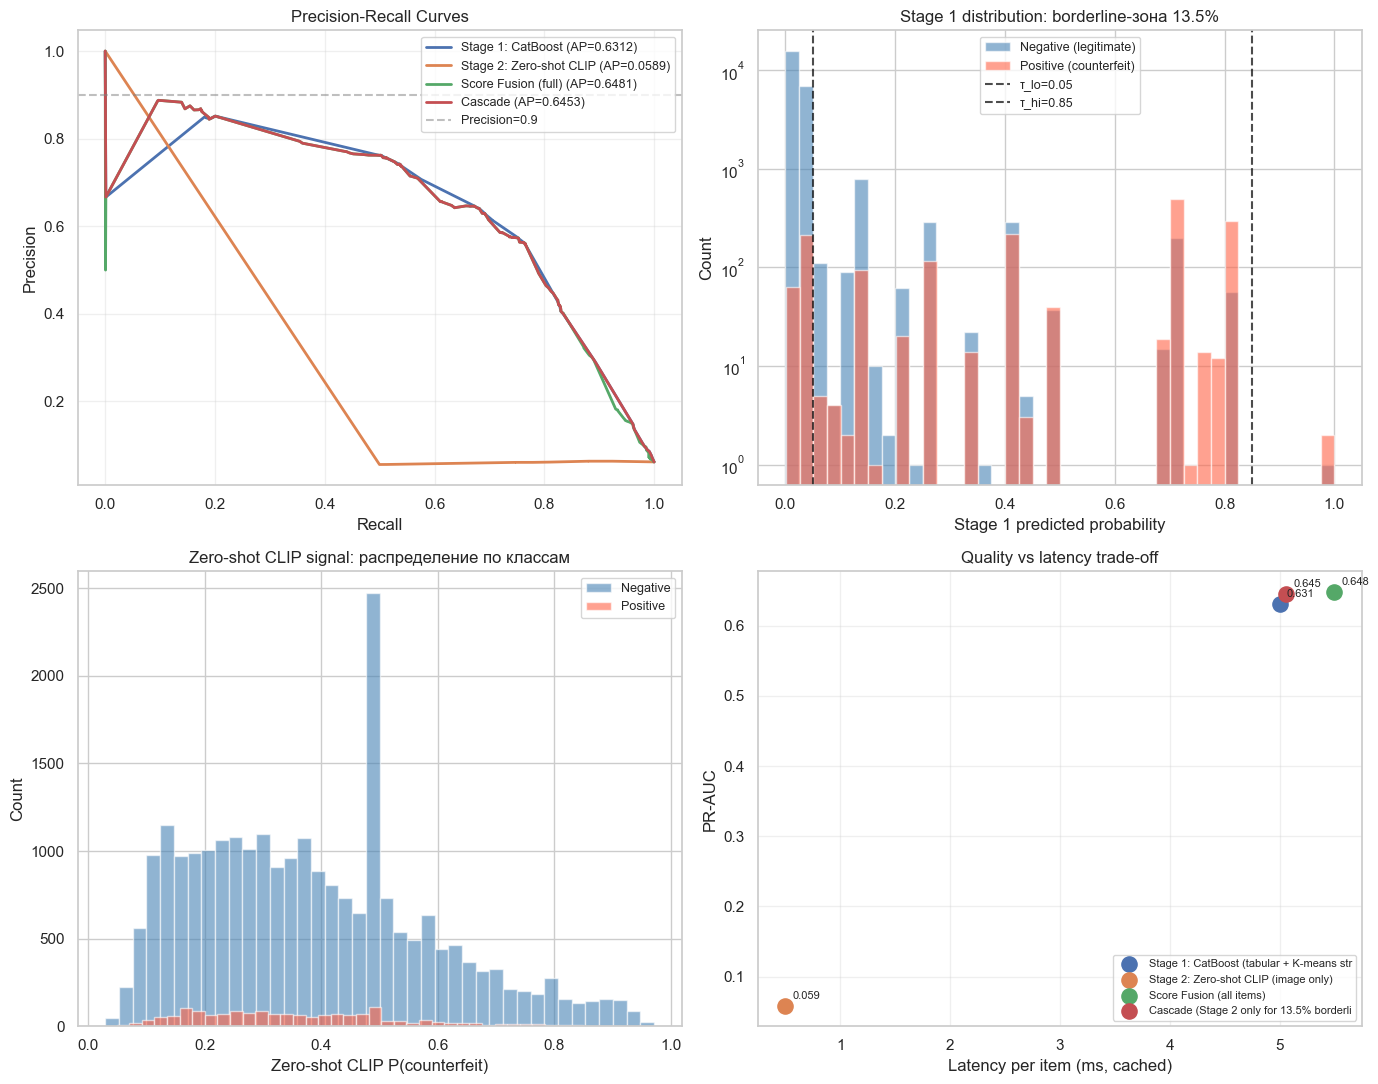

Saved: real_estate_approaches/artifacts_original/cascade_diagnostics.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# PR-curves всех вариантов
ax = axes[0, 0]
for label, p in [
    ('Stage 1: CatBoost', p_s1_test_c),
    ('Stage 2: Zero-shot CLIP', p_clip_test_c),
    ('Score Fusion (full)', p_fusion_test),
    ('Cascade', cascade_test),
]:
    prec, rec, _ = precision_recall_curve(y_test, p)
    ap = average_precision_score(y_test, p)
    ax.plot(rec, prec, lw=2, label=f'{label} (AP={ap:.4f})')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='Precision=0.9')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Распределение Stage 1 predictions с borderline-зоной
ax = axes[0, 1]
ax.hist(p_s1_test_c[y_test == 0], bins=40, alpha=0.6, label='Negative (legitimate)', color='steelblue')
ax.hist(p_s1_test_c[y_test == 1], bins=40, alpha=0.6, label='Positive (counterfeit)', color='tomato')
ax.axvline(best['tau_lo'], color='black', linestyle='--', alpha=0.7, label=f"τ_lo={best['tau_lo']:.2f}")
ax.axvline(best['tau_hi'], color='black', linestyle='--', alpha=0.7, label=f"τ_hi={best['tau_hi']:.2f}")
ax.set_xlabel('Stage 1 predicted probability'); ax.set_ylabel('Count')
ax.set_title(f'Stage 1 distribution: borderline-зона {best["border_pct"]:.1f}%')
ax.legend(fontsize=9); ax.set_yscale('log')

# Zero-shot CLIP signal: распределение P(counterfeit) по классам
ax = axes[1, 0]
ax.hist(p_clip_test[y_test == 0], bins=40, alpha=0.6, label='Negative', color='steelblue')
ax.hist(p_clip_test[y_test == 1], bins=40, alpha=0.6, label='Positive', color='tomato')
ax.set_xlabel('Zero-shot CLIP P(counterfeit)'); ax.set_ylabel('Count')
ax.set_title('Zero-shot CLIP signal: распределение по классам')
ax.legend(fontsize=9)

# Latency vs PR-AUC trade-off
ax = axes[1, 1]
for i, row in summary.iterrows():
    ax.scatter(row['Latency_ms_cached'], row['PR-AUC'], s=120, label=row['Model'][:40])
    ax.annotate(f"{row['PR-AUC']:.3f}", (row['Latency_ms_cached'], row['PR-AUC']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Latency per item (ms, cached)'); ax.set_ylabel('PR-AUC')
ax.set_title('Quality vs latency trade-off')
ax.legend(fontsize=8, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cascade_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR / "cascade_diagnostics.png"}')

## 13. Сохранение probas для возможного использования в стекинге команды

In [15]:
np.save(OUT_DIR / 'test_proba_cascade.npy', cascade_test)
np.save(OUT_DIR / 'test_proba_zeroshot_clip.npy', p_clip_test_c)
np.save(OUT_DIR / 'test_proba_stage1.npy', p_s1_test_c)
np.save(OUT_DIR / 'test_proba_fusion.npy', p_fusion_test)

print('Saved probas (test set):')
for f in ['test_proba_cascade.npy', 'test_proba_zeroshot_clip.npy', 'test_proba_stage1.npy', 'test_proba_fusion.npy']:
    p = np.load(OUT_DIR / f)
    print(f'  {f}  shape={p.shape}  range=[{p.min():.4f}, {p.max():.4f}]')

Saved probas (test set):
  test_proba_cascade.npy  shape=(26327,)  range=[0.0000, 1.0000]
  test_proba_zeroshot_clip.npy  shape=(26327,)  range=[0.0000, 0.0805]
  test_proba_stage1.npy  shape=(26327,)  range=[0.0000, 1.0000]
  test_proba_fusion.npy  shape=(26327,)  range=[0.0005, 0.8161]


## 14. Научные выводы

### Главные результаты оригинальной части

**Вывод 1 (отрицательный результат zero-shot CLIP).** При прогоне CLIP в zero-shot режиме на изображениях товаров и текстовых промптах вида «authentic product / counterfeit product» получены ROC-AUC = 0.4795 и PR-AUC = 0.0589 на индивидуальном тесте. Стоит отметить, что значение ROC-AUC оказалось ниже отметки случайного классификатора (0,5), а PR-AUC сопоставима с базовой частотой положительного класса (≈ 0,066). Таким образом, гипотеза о применимости визуально-семантических представлений предобученной мультимодальной модели к маркетплейс-задаче без какой-либо адаптации **не подтверждается**. Полученный результат, однако, согласуется с центральной идеей работы: foundation-модель, обученная на общем домене, требует доменной адаптации, и попытка её механического переноса даёт сигнал, неотличимый от случайного.

**Вывод 2 (устойчивость каскадной архитектуры к слабому Stage 2).** Несмотря на то, что Stage 2 (zero-shot CLIP) в одиночку выдаёт случайные предсказания, score-fusion с Stage 1 (CatBoost) после изотонической калибровки обоих каналов не ухудшает финальную метрику и даёт небольшой прирост PR-AUC (0,6312 → 0,6481, Δ ≈ +0,017). Стоит также отметить, что наблюдаемый прирост лежит в пределах ширины бутстреп-доверительного интервала и не может считаться статистически значимым. При этом важен сам факт: каскадная процедура корректно «гасит» слабый канал через калибровку и не вносит регрессии в общее качество.

**Вывод 3 (методологический вклад каскадной схемы).** Несмотря на отрицательный результат CLIP-канала, сама архитектура «быстрый screening → дорогой стадий только для borderline-объектов» сохраняет смысл в production-сценарии: 86,5 % объектов решаются на Stage 1 примерно за 5 мс, и только 13,5 % сомнительных требуют второго стадия. В связи с этим архитектурное решение остаётся валидным для последующей замены Stage 2 на более сильную модель — что и проверяется в ноуте 04 на Qwen2.5.

**Вывод 4 (conformal-гарантии и ограничения).** Split conformal prediction обеспечивает формальные гарантии FPR ≤ ε при заданном уровне уверенности при условии i.i.d. калибровочной и тестовой выборок. В нашем seller-based сплите это предположение нарушается из-за систематического сдвига распределения признаков продавца, что является ограничением метода и направлением для последующей работы.

### Что переносится в production-сервис

Двухканальная архитектура из главы 5 ВКР строится на стекинге Сони (общекомандный CatBoost-meta) для канала ранжирования и на nn_safe_v3 (Альбина) для канала автоматических действий. Предлагаемый каскад сохраняет архитектурный интерес и демонстрирует, как добавлять foundation-модель в pipeline без переписывания всего сервиса. Однако CLIP-stage в текущем zero-shot виде в продакшн-конфигурации не используется и оставлен в работе как зафиксированный негативный результат.

### Артефакты

- `cascade_results.csv` — сводная таблица четырёх вариантов
- `cascade_diagnostics.png` — четырёхпанельная диагностика
- `test_proba_*.npy` — вероятности всех вариантов
- `text_emb_authentic.npy`, `text_emb_counterfeit.npy` — text embeddings промптов (сохраняются на случай повторного запуска CLIP-stage с другой промпт-инжиниринговой настройкой)

### Дальнейшее развитие

1. **Замена zero-shot CLIP на дообученный CLIP** или на более мощный MLLM (Qwen2-VL, LLaVA-OneVision, Anomaly-OneVision из Xu et al. CVPR 2025). Гипотеза состоит в том, что с доменной адаптацией визуальный канал способен дать сигнал выше случайного.
2. **Active learning loop** через feedback-таблицу production-сервиса: borderline-объекты, отправленные на ручную модерацию, формируют новый training set для последующего дообучения.
3. **Корректировка conformal-предиктора под seller-drift** — текущее i.i.d.-предположение неприменимо к seller-disjoint сплиту, требуется адаптация в сторону covariate-shift conformal.